In [1]:
import h5py 
import dxchange
import os
import numpy as np
from holotomocupy.utils import *

astropy module not found
olefile module not found


## Parameters

In [2]:
n = 2048
ntheta = 1800
detector_pixelsize = 1.4760147601476e-6 * 2
energy = 33.35
wavelength = 1.24e-09 / energy
focustodetectordistance = 1.2889995

sx0 = 1.28e-3
z1 = np.array([7.393, 7.655, 8.704, 10.882]) * 1e-3 - sx0
ndist = len(z1)
z2 = focustodetectordistance - z1

distances = (z1 * z2) / focustodetectordistance
magnifications = focustodetectordistance / z1
norm_magnifications = magnifications / magnifications[0]
voxelsizes = np.abs(detector_pixelsize / magnifications)
voxelsize = voxelsizes[0]

path = '/data2/vnikitin/atomium/20250607/AtomiumL1//'
pfile = 'AtomiumL1_HT_014nm'
path_out = '/data2/vnikitin/atomium_rec/20250607/AtomiumL1/'
file_out = f'data.h5'

print(voxelsize)
#1009.624036


1.3999816491445155e-08


In [ ]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],  # fallbacks
})
# mpl.rcParams['font.size'] = 28  # optional

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",   # Times-like math
    # optional:
    # "mathtext.default": "regular",
})
mpl.rcParams["xtick.labelsize"] = 22
mpl.rcParams["ytick.labelsize"] = 22
def mshow(a, show=False, **args):
    if show:
        if isinstance(a, cp.ndarray):
            a = a.get()
        fig, axs = plt.subplots(1, 1, figsize=(6,6))
        im = axs.imshow(a, cmap="gray", **args)
        cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
        scalebar = ScaleBar(14e-3, "um", length_fraction=0.25, font_properties={
            "family": "serif","fontsize": 22,
        },  # For more information, see the cell below                
        location="lower right")
        cbar.ax.tick_params(labelsize=28)
        axs.add_artist(scalebar)
        # plt.show()


### Parse files and save everything to h5

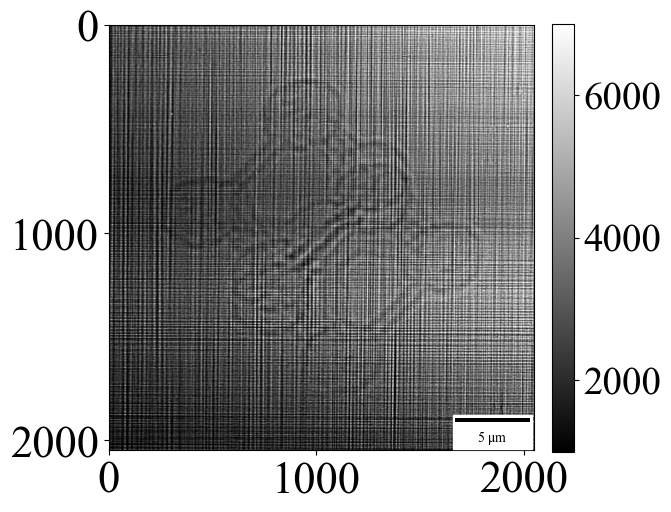

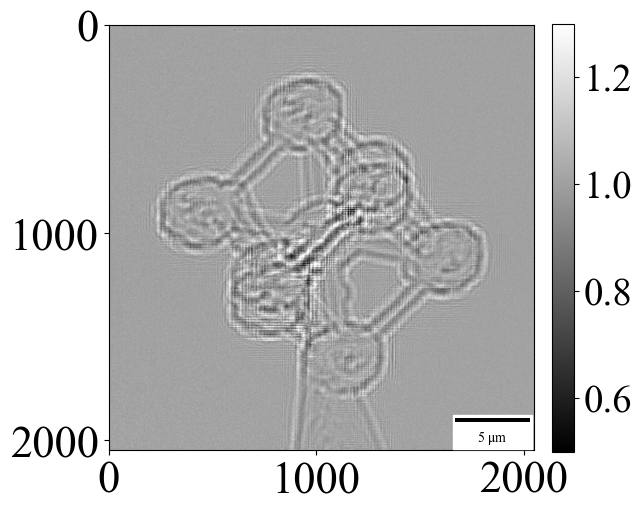

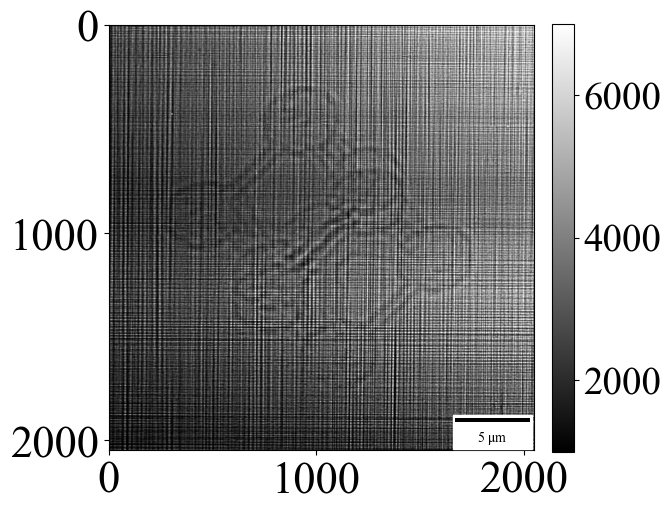

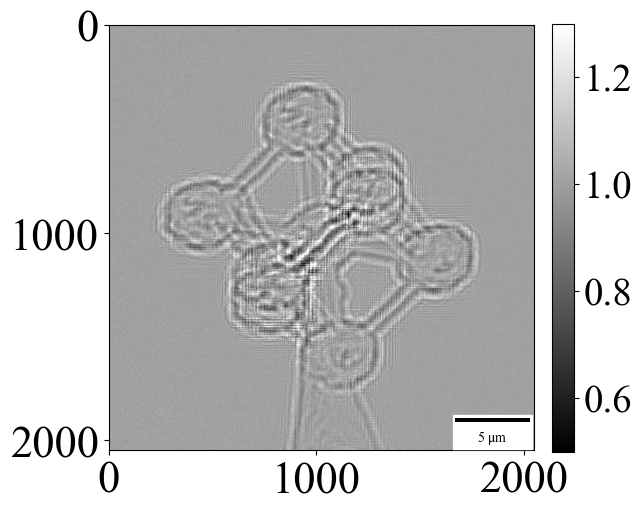

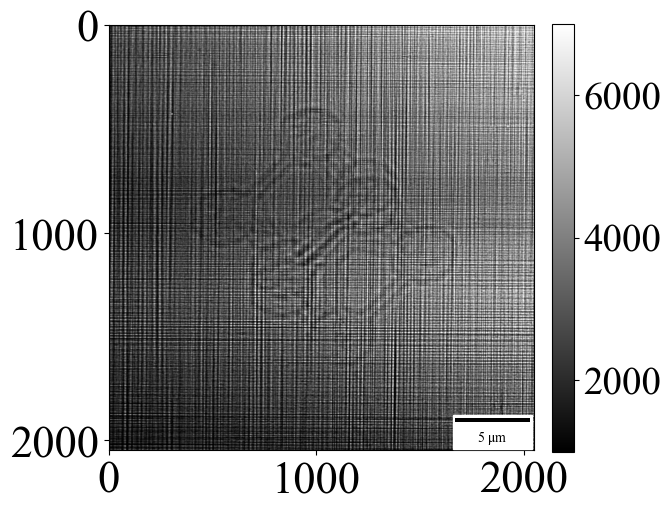

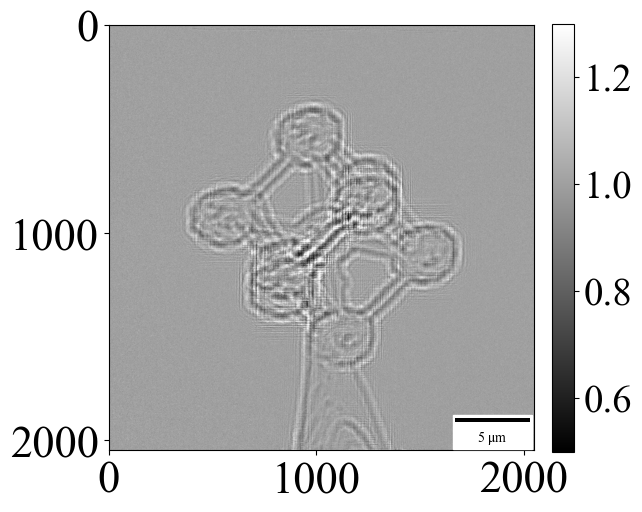

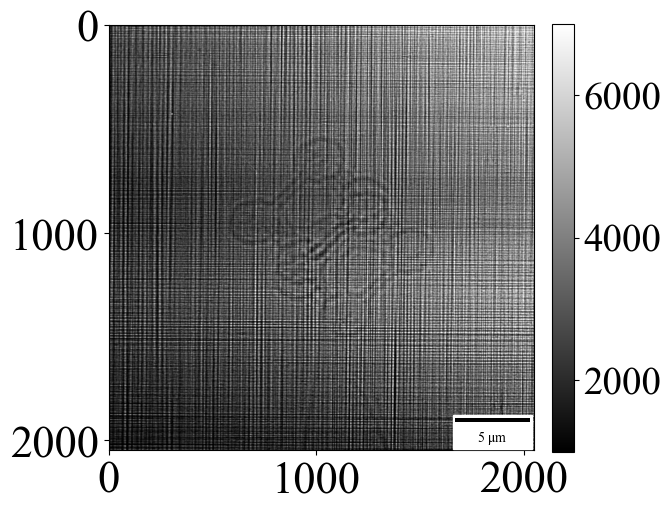

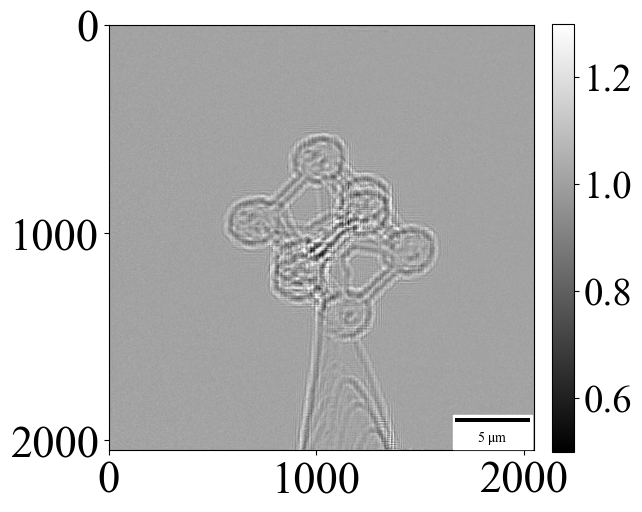

In [8]:
os.makedirs(path_out, exist_ok=True)
for k in range(0,ndist):
    dname = f'{path}/{pfile}_{k+1}_'

    [n0,n1] = dxchange.read_edf(f'{dname}/ref{0:04}_0000.edf')[0].shape
    sty,endy = n0//2 - n//2,n0//2 + n//2
    stx,endx = n1//2 - n//2,n1//2 + n//2
    for id in range(20):
        data_white0 = dxchange.read_edf(f'{dname}/ref{id:04}_0000.edf')[0][sty:endy,stx:endx]
        
    for id in range(1):
        fname = f'{dname}/{pfile}_{k+1}_{id:04}.edf'
        
        data = dxchange.read_edf(fname)[0][sty:endy,stx:endx]
        
        mshow(data,True,vmax=7000,vmin=1000)
        plt.savefig(f"figs/data{k}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)

        
        mshow(data/data_white0,True,vmax=1.3,vmin=0.5)
        plt.savefig(f"figs/rdata{k}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)